# Spotify analysis

In [0]:
%restart_python

# Install packages

In [0]:
!pip install spotipy

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Import libraries

In [0]:
# basic packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# spotify packages

import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Invoke Spotify client

In [0]:
# create a proyect and retrieval the credentials

# https://developer.spotify.com/documentation/web-api

client_id = "42e39ebda6fc49d48d9a3b3548317b88"
client_secret = "2b200bcd78284aa4b6e2c8a041e536e9" 

In [0]:
# create a Spotify client

client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

# Search a playlist

In [0]:
playlist_name = 'regueton'
playlist_results = sp.search(q=playlist_name, type='playlist')

In [0]:
playlist_selected = playlist_results['playlists']['items'][0]

In [0]:
playlist_name_s = playlist_selected['name']
playlist_id_s = playlist_selected['id']
playlist_name_s, playlist_id_s

(' REGUETÓN 2026 🔥MIX REGGAETON SUMMER 2026 😍 REGUETÓN EXITOS 2026 😍LO MAS NUEVO MUSICA REGUETÓN 2026',
 '79emz4GMzwgJaytiuczD0D')

# Retrieval track data

In [0]:
playlist_id_s = '5NvuFYJRIJQ9B3bEELa7Yi'

In [0]:
top_tracks = sp.playlist_tracks(playlist_id_s,limit=100)

# Data exploration

In [0]:
top_tracks

{'href': 'https://api.spotify.com/v1/playlists/5NvuFYJRIJQ9B3bEELa7Yi/items?offset=0&limit=100&additional_types=track',
 'items': [{'added_at': '2024-04-13T16:13:22Z',
   'added_by': {'external_urls': {'spotify': 'https://open.spotify.com/user/314n5q6goyhvg4ue7mudbqpghdzq'},
    'href': 'https://api.spotify.com/v1/users/314n5q6goyhvg4ue7mudbqpghdzq',
    'id': '314n5q6goyhvg4ue7mudbqpghdzq',
    'type': 'user',
    'uri': 'spotify:user:314n5q6goyhvg4ue7mudbqpghdzq'},
   'is_local': False,
   'primary_color': None,
   'track': {'preview_url': None,
    'available_markets': ['AR',
     'AU',
     'AT',
     'BE',
     'BO',
     'BR',
     'BG',
     'CA',
     'CL',
     'CO',
     'CR',
     'CY',
     'CZ',
     'DK',
     'DO',
     'DE',
     'EC',
     'EE',
     'SV',
     'FI',
     'FR',
     'GR',
     'GT',
     'HN',
     'HK',
     'HU',
     'IS',
     'IE',
     'IT',
     'LV',
     'LT',
     'LU',
     'MY',
     'MT',
     'MX',
     'NL',
     'NZ',
     'NI',
     'N

In [0]:
top_tracks['items'][0]['track'].keys()

dict_keys(['preview_url', 'available_markets', 'explicit', 'type', 'episode', 'track', 'album', 'artists', 'disc_number', 'track_number', 'duration_ms', 'external_ids', 'external_urls', 'href', 'id', 'name', 'popularity', 'uri', 'is_local'])

In [0]:
top_tracks['items'][0]['track']['album'].keys()

dict_keys(['available_markets', 'type', 'album_type', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'uri', 'artists', 'external_urls', 'total_tracks'])

# Generate playlist

In [0]:
# extract more attributes from each track

list_all_song = []

for track in top_tracks['items']:
    t = track['track']
    if t is None:
        continue

    track_name = t['name']
    track_id = t['id']
    popularity = t['popularity']
    explicit = t['explicit']
    duration_min = t['duration_ms'] / 60000
    track_number = t['track_number']
    num_markets = len(t.get('available_markets', []))

    artists = t['artists']
    artist_name = artists[0]['name']
    artist_id = artists[0]['id']
    all_artists = ', '.join(a['name'] for a in artists)
    num_artists = len(artists)

    album = t['album']
    album_name = album['name']
    album_type = album['album_type']
    total_tracks_album = album['total_tracks']
    release_date = album['release_date']

    list_all_song.append({
        'track_name': track_name,
        'track_id': track_id,
        'artist_name': artist_name,
        'artist_id': artist_id,
        'all_artists': all_artists,
        'num_artists': num_artists,
        'popularity': popularity,
        'explicit': explicit,
        'album_name': album_name,
        'album_type': album_type,
        'total_tracks_album': total_tracks_album,
        'track_number': track_number,
        'num_markets': num_markets,
        'release_date': release_date,
        'duration_min': duration_min,
    })

df_all_songs = pd.DataFrame(list_all_song)
df_all_songs.head()

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min
0,Thunderstruck,57bgtoPSgt236HzfBOd8kj,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,89,False,The Razors Edge,album,12,1,185,1990-09-24,4.872217
1,Welcome To The Jungle,0G21yYKMZoHa30cYVi1iA8,Guns N' Roses,3qm84nBOXUEQ2vnTfUTTFC,Guns N' Roses,1,86,True,Appetite For Destruction,album,12,1,183,1987-07-21,4.558000
2,Smells Like Teen Spirit,5ghIJDpPoe3CfHMGu71E6T,Nirvana,6olE6TJLqED3rqDCT0FyPh,Nirvana,1,83,False,Nevermind (Remastered),album,13,1,3,1991-09-26,5.032000
3,Livin' On A Prayer,37ZJ0p5Jm13JPevGcx4SkF,Bon Jovi,58lV9VcRSjABbAbfWS6skp,Bon Jovi,1,84,False,Slippery When Wet,album,10,3,184,1986-08-16,4.154883
4,I Was Made For Lovin' You,07q0QVgO56EorrSGHC48y3,KISS,07XSN3sPlIlB2L2XNcTwJw,KISS,1,87,False,Dynasty,album,9,1,183,1979-03-23,4.520667


In [0]:
df_all_songs.shape

(100, 15)

In [0]:
df_all_songs.dtypes

track_name             object
track_id               object
artist_name            object
artist_id              object
all_artists            object
num_artists             int64
popularity              int64
explicit                 bool
album_name             object
album_type             object
total_tracks_album      int64
track_number            int64
num_markets             int64
release_date           object
duration_min          float64
dtype: object

In [0]:
# cast date and add release year

df_all_songs['release_date'] = pd.to_datetime(df_all_songs['release_date'], errors='coerce')
df_all_songs['release_year'] = df_all_songs['release_date'].dt.year

In [0]:
def get_bracket_date(x):

    if pd.isna(x):
        return 'Sin fecha'

    if x <= pd.Timestamp('2000-01-01'):
        return 'Antes de los 2000'
    elif x <= pd.Timestamp('2010-01-01'):
        return 'Entre 2000 y 2010'
    elif x <= pd.Timestamp('2020-01-01'):
        return 'Entre 2010 y 2020'
    else:
        return 'Después de 2020' 

In [0]:
df_all_songs['release_date_bracket'] = df_all_songs['release_date'].apply(get_bracket_date)

# Enrich with artist data

Get followers, popularity and genres per artist (one batched call).

In [0]:
# unique artist ids from the playlist

unique_artist_ids = df_all_songs['artist_id'].dropna().unique().tolist()
len(unique_artist_ids)

36

In [0]:
# batched calls (max 50 per call)

artist_data = {}

for i in range(0, len(unique_artist_ids), 50):
    batch = unique_artist_ids[i:i+50]
    res = sp.artists(batch)
    for a in res['artists']:
        artist_data[a['id']] = {
            'artist_followers': a['followers']['total'],
            'artist_popularity': a['popularity'],
            'artist_genres': ', '.join(a['genres']) if a['genres'] else None,
        }

df_artists = pd.DataFrame.from_dict(artist_data, orient='index').reset_index().rename(columns={'index': 'artist_id'})
df_artists.head()

,artist_id,artist_followers,artist_popularity,artist_genres
0,711MCceyCBcFnzjGY4Q7Un,34116016,82,"rock, hard rock, classic rock, rock and roll"
1,3qm84nBOXUEQ2vnTfUTTFC,37484999,80,"rock, glam metal, hard rock, classic rock"
2,6olE6TJLqED3rqDCT0FyPh,25417186,82,"grunge, rock"
3,58lV9VcRSjABbAbfWS6skp,16950562,79,glam metal
4,07XSN3sPlIlB2L2XNcTwJw,11823844,72,"glam rock, glam metal, hard rock, rock, classi..."


In [0]:
# merge into main dataframe

df_all_songs = df_all_songs.merge(df_artists, on='artist_id', how='left')
df_all_songs.head()

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
0,Thunderstruck,57bgtoPSgt236HzfBOd8kj,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,89,False,The Razors Edge,album,12,1,185,1990-09-24,4.872217,1990.0,Antes de los 2000,34116016,82,"rock, hard rock, classic rock, rock and roll"
1,Welcome To The Jungle,0G21yYKMZoHa30cYVi1iA8,Guns N' Roses,3qm84nBOXUEQ2vnTfUTTFC,Guns N' Roses,1,86,True,Appetite For Destruction,album,12,1,183,1987-07-21,4.558000,1987.0,Antes de los 2000,37484999,80,"rock, glam metal, hard rock, classic rock"
2,Smells Like Teen Spirit,5ghIJDpPoe3CfHMGu71E6T,Nirvana,6olE6TJLqED3rqDCT0FyPh,Nirvana,1,83,False,Nevermind (Remastered),album,13,1,3,1991-09-26,5.032000,1991.0,Antes de los 2000,25417186,82,"grunge, rock"
3,Livin' On A Prayer,37ZJ0p5Jm13JPevGcx4SkF,Bon Jovi,58lV9VcRSjABbAbfWS6skp,Bon Jovi,1,84,False,Slippery When Wet,album,10,3,184,1986-08-16,4.154883,1986.0,Antes de los 2000,16950562,79,glam metal
4,I Was Made For Lovin' You,07q0QVgO56EorrSGHC48y3,KISS,07XSN3sPlIlB2L2XNcTwJw,KISS,1,87,False,Dynasty,album,9,1,183,1979-03-23,4.520667,1979.0,Antes de los 2000,11823844,72,"glam rock, glam metal, hard rock, rock, classi..."


In [0]:
# df_all_songs.to_csv('regueton_playlist.csv', index=False)

# Descriptive analysis

In [0]:
# the top 10 popular songs

df_all_songs.sort_values('popularity', ascending=False).head(10)

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
0,Thunderstruck,57bgtoPSgt236HzfBOd8kj,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,89,False,The Razors Edge,album,12,1,185,1990-09-24,4.872217,1990.0,Antes de los 2000,34116016,82,"rock, hard rock, classic rock, rock and roll"
8,Highway to Hell,2zYzyRzz6pRmhPzyfMEC8s,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,89,False,Highway to Hell,album,10,1,185,1979-07-27,3.468500,1979.0,Antes de los 2000,34116016,82,"rock, hard rock, classic rock, rock and roll"
66,Back In Black,08mG3Y1vljYA6bvDt4Wqkj,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,88,False,Back In Black,album,10,6,185,1980-07-25,4.266667,1980.0,Antes de los 2000,34116016,82,"rock, hard rock, classic rock, rock and roll"
4,I Was Made For Lovin' You,07q0QVgO56EorrSGHC48y3,KISS,07XSN3sPlIlB2L2XNcTwJw,KISS,1,87,False,Dynasty,album,9,1,183,1979-03-23,4.520667,1979.0,Antes de los 2000,11823844,72,"glam rock, glam metal, hard rock, rock, classi..."
85,Sultans Of Swing,37Tmv4NnfQeb0ZgUC4fOJj,Dire Straits,0WwSkZ7LtFUFjGjMZBMt6T,Dire Straits,1,87,False,Dire Straits,album,9,6,182,1978-10-07,5.806667,1978.0,Antes de los 2000,9492087,78,classic rock
1,Welcome To The Jungle,0G21yYKMZoHa30cYVi1iA8,Guns N' Roses,3qm84nBOXUEQ2vnTfUTTFC,Guns N' Roses,1,86,True,Appetite For Destruction,album,12,1,183,1987-07-21,4.558000,1987.0,Antes de los 2000,37484999,80,"rock, glam metal, hard rock, classic rock"
20,Enter Sandman - Remastered 2021,3DwQ7AH3xGD9h65ezslm6q,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,86,False,Metallica (Remastered Deluxe Box Set),album,193,1,182,2021-09-10,5.526000,2021.0,Después de 2020,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
19,You Shook Me All Night Long,2SiXAy7TuUkycRVbbWDEpo,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,86,False,Back In Black,album,10,7,185,1980-07-25,3.505467,1980.0,Antes de los 2000,34116016,82,"rock, hard rock, classic rock, rock and roll"
11,"Another Brick in the Wall, Pt. 2",4gMgiXfqyzZLMhsksGmbQV,Pink Floyd,0k17h0D3J5VfsdmQ1iZtE9,Pink Floyd,1,85,False,The Wall,album,26,5,185,1979-11-30,3.982433,1979.0,Antes de los 2000,23856120,80,"progressive rock, psychedelic rock, classic ro..."
77,Dancing In the Dark,7FwBtcecmlpc1sLySPXeGE,Bruce Springsteen,3eqjTLE0HfPfh78zjh6TqT,Bruce Springsteen,1,85,False,Born In The U.S.A.,album,12,11,185,1984-06-04,4.088267,1984.0,Antes de los 2000,7793780,76,None


In [0]:
# top 10 most lang songs

df_all_songs.sort_values('duration_min', ascending=False).head(10)

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
49,Kashmir - Remaster,6Vjk8MNXpQpi0F4BefdTyq,Led Zeppelin,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,1,73,False,Physical Graffiti (Deluxe Edition),album,22,6,122,1975-02-24,8.618750,1975.0,Antes de los 2000,16743591,77,"classic rock, rock, hard rock, rock and roll"
36,Master Of Puppets,2MuWTIM3b0YEAskbeeFE1i,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,82,False,Master Of Puppets (Remastered),album,8,2,182,1986-03-03,8.589767,1986.0,Antes de los 2000,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
90,Fade To Black - Remastered,5nekfiTN45vlxG0eNJQQye,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,69,False,Ride The Lightning (Deluxe / Remastered),compilation,64,4,182,1984-07-26,6.953767,1984.0,Antes de los 2000,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
14,Paradise City,6eN1f9KNmiWEhpE2RhQqB5,Guns N' Roses,3qm84nBOXUEQ2vnTfUTTFC,Guns N' Roses,1,85,False,Appetite For Destruction,album,12,6,183,1987-07-21,6.760000,1987.0,Antes de los 2000,37484999,80,"rock, glam metal, hard rock, classic rock"
29,The Unforgiven - Remastered 2021,5lqyqPU3JkpCbUbLmTVQPW,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,77,False,Metallica (Remastered 2021),album,12,4,182,2021-09-10,6.452667,2021.0,Después de 2020,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
42,Money,0vFOzaXqZHahrZp6enQwQb,Pink Floyd,0k17h0D3J5VfsdmQ1iZtE9,Pink Floyd,1,78,True,The Dark Side of the Moon,album,10,6,185,1973-03-01,6.334667,1973.0,Antes de los 2000,23856120,80,"progressive rock, psychedelic rock, classic ro..."
76,Sympathy For The Devil - 50th Anniversary Edition,1Ud6moTC0KyXMq1Oxfien0,The Rolling Stones,22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,1,77,False,Beggars Banquet (50th Anniversary Edition),album,10,1,184,1968-12-06,6.302433,1968.0,Antes de los 2000,16437135,78,"classic rock, rock"
79,Turn The Page,1aXFBWnnPFRKUN7vuIA5h0,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,70,False,Garage Inc.,compilation,27,4,182,1998-01-01,6.107767,1998.0,Antes de los 2000,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
48,Highway Star - Remastered 2012,3uMmllZo1AfoEnVT4ENCD3,Deep Purple,568ZhdwyaiCyOGJRtNYhWf,Deep Purple,1,69,False,Machine Head (Remastered),album,8,1,181,1972-03-25,6.102267,1972.0,Antes de los 2000,6184390,66,"hard rock, classic rock, rock"
58,Burn - Remastered 2004,1iW2ktyrQHNKZwFTvgP0Ta,Deep Purple,568ZhdwyaiCyOGJRtNYhWf,Deep Purple,1,61,False,Burn (30th Anniversary Edition),album,13,1,181,1974-02-15,6.082217,1974.0,Antes de los 2000,6184390,66,"hard rock, classic rock, rock"


In [0]:
# top 10 most short songs

df_all_songs.sort_values('duration_min', ascending=True).head(10)

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
9,We Will Rock You - Remastered 2011,4pbJqGIASGPr0ZpGpnWkDn,Queen,1dfeR4HaWDbWqFHLkxsg1d,Queen,1,80,False,News Of The World (2011 Remaster),album,11,1,178,1977-10-28,2.034433,1977.0,Antes de los 2000,57432665,84,"classic rock, rock, glam rock"
24,Break on Through (To the Other Side),6ToM0uwxtPKo9CMpbPGYvM,The Doors,22WZ7M8sxp5THdruNY3gXt,The Doors,1,74,False,The Doors,album,11,1,184,1967-01-04,2.431100,1967.0,Antes de los 2000,9250455,72,"psychedelic rock, classic rock, acid rock"
6,Immigrant Song - Remaster,78lgmZwycJ3nzsdgmPPGNx,Led Zeppelin,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,1,81,False,Led Zeppelin III (Remaster),album,10,1,185,NaT,2.437500,NaN,Sin fecha,16743591,77,"classic rock, rock, hard rock, rock and roll"
45,I Wanna Be Sedated,5NoQvINZLBV1wMYPdNmReL,Ramones,1co4F2pPNH8JjTutZkmgSm,Ramones,1,71,False,Road to Ruin (40th Anniversary Deluxe Edition),album,80,7,184,NaT,2.496433,NaN,Sin fecha,3002047,65,"punk, proto-punk"
95,Dumb,5gRcv46AMTrosmTOqrOV3Q,Nirvana,6olE6TJLqED3rqDCT0FyPh,Nirvana,1,75,False,In Utero,album,12,6,184,1993-09-21,2.531550,1993.0,Antes de los 2000,25417186,82,"grunge, rock"
50,Breaking the Law,2RaA6kIcvomt77qlIgGhCT,Judas Priest,2tRsMl4eGxwoNabM08Dm4I,Judas Priest,1,72,False,British Steel,album,11,3,185,NaT,2.564000,NaN,Sin fecha,4703689,65,"heavy metal, metal, hard rock, glam metal, spe..."
94,Green River,11DjZQEZ69EXLo77HVj6yW,Creedence Clearwater Revival,3IYUhFvPQItj6xySrBmZkd,Creedence Clearwater Revival,1,76,False,Green River (Expanded Edition),album,14,1,184,1969-08-03,2.568667,1969.0,Antes de los 2000,8468536,78,"classic rock, southern rock, country rock"
59,Good Times Bad Times - 1993 Remaster,0QwZfbw26QeUoIy82Z2jYp,Led Zeppelin,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,1,70,False,Led Zeppelin,album,9,1,185,1969-01-12,2.771100,1969.0,Antes de los 2000,16743591,77,"classic rock, rock, hard rock, rock and roll"
55,Live And Let Die,0rFWuqFgHAfuzE8uSB9TWR,Guns N' Roses,3qm84nBOXUEQ2vnTfUTTFC,Guns N' Roses,1,74,False,Use Your Illusion I,album,16,3,184,1991-09-17,3.045550,1991.0,Antes de los 2000,37484999,80,"rock, glam metal, hard rock, classic rock"
78,Run Through The Jungle,5VfgDw3oOzcNoszDwkLQhH,Creedence Clearwater Revival,3IYUhFvPQItj6xySrBmZkd,Creedence Clearwater Revival,1,74,False,Cosmo's Factory,album,11,6,183,1970-07-24,3.085100,1970.0,Antes de los 2000,8468536,78,"classic rock, southern rock, country rock"


In [0]:
# new songs

df_all_songs.sort_values('release_date', ascending=False).head(10)

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
29,The Unforgiven - Remastered 2021,5lqyqPU3JkpCbUbLmTVQPW,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,77,False,Metallica (Remastered 2021),album,12,4,182,2021-09-10,6.452667,2021.0,Después de 2020,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
20,Enter Sandman - Remastered 2021,3DwQ7AH3xGD9h65ezslm6q,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,86,False,Metallica (Remastered Deluxe Box Set),album,193,1,182,2021-09-10,5.526000,2021.0,Después de 2020,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"
16,No One Like You,5hVepr5CHiTGtJY5bP4i5n,Scorpions,27T030eWyCQRmDyuvr1kxY,Scorpions,1,62,False,Comeblack,album,13,2,185,2011-11-07,4.108883,2011.0,Entre 2010 y 2020,9244576,74,"hard rock, glam metal, rock"
46,Rock N Roll Train,4feXJ5IC3avXsVW9WNFSag,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,73,False,Black Ice,album,15,1,185,2008-10-20,4.335400,2008.0,Entre 2000 y 2010,34116016,82,"rock, hard rock, classic rock, rock and roll"
40,Poison,39J10NL0mFTAdJbapoo2rC,Alice Cooper,3EhbVgyfGd7HkpsagwL9GS,Alice Cooper,1,53,False,The Best Of Alice Cooper,compilation,15,1,183,2007-05-05,4.513100,2007.0,Entre 2000 y 2010,4145575,62,"glam rock, hard rock, glam metal, proto-punk, ..."
15,Unskinny Bop,7ba7mwoleFlwmOiuqw8XNf,Poison,1fBCIkoPOPCDLUxGuWNvyo,Poison,1,49,False,The Best Of - 20 Years Of Rock,compilation,18,10,184,2006-01-01,3.819333,2006.0,Entre 2000 y 2010,3710897,63,"glam metal, glam rock"
37,God Gave Me Everything,020X55mawvXGASoewg14Dj,Mick Jagger,3d2pb1dHTm8b61zAGVUVvO,Mick Jagger,1,55,False,Goddess In The Doorway,album,13,4,184,2001-11-19,3.570000,2001.0,Entre 2000 y 2010,757535,51,None
13,It's My Life,0v1XpBHnsbkCn7iJ9Ucr1l,Bon Jovi,58lV9VcRSjABbAbfWS6skp,Bon Jovi,1,84,False,Crush,album,12,1,184,2000-01-01,3.741550,2000.0,Antes de los 2000,16950562,79,glam metal
68,American Woman,3X6iIrFuQoCshIWBseEKPl,Lenny Kravitz,5gznATMVO85ZcLTkE9ULU7,Lenny Kravitz,1,68,False,5,album,15,14,184,1998-05-12,4.409333,1998.0,Antes de los 2000,3820717,73,None
43,Whiskey In The Jar,2R6UrJ8uWbSIiHWmvRQvN8,Metallica,2ye2Wgw4gimLv2eAKyk1NB,Metallica,1,77,False,Garage Inc.,compilation,27,9,182,1998-01-01,5.078217,1998.0,Antes de los 2000,34504337,83,"metal, thrash metal, rock, heavy metal, hard rock"


In [0]:
# old songs

df_all_songs.sort_values('release_date', ascending=True).head(10)

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
54,(I Can't Get No) Satisfaction - Mono,2PzU4IB8Dr6mxV3lHuaG34,The Rolling Stones,22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,1,75,False,Out Of Our Heads,compilation,12,7,184,1965-07-30,3.713550,1965.0,Antes de los 2000,16437135,78,"classic rock, rock"
5,"Paint It, Black",63T7DJ1AFDD6Bn8VzG6JE8,The Rolling Stones,22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,1,85,False,Aftermath,album,11,1,184,1966-04-15,3.371100,1966.0,Antes de los 2000,16437135,78,"classic rock, rock"
24,Break on Through (To the Other Side),6ToM0uwxtPKo9CMpbPGYvM,The Doors,22WZ7M8sxp5THdruNY3gXt,The Doors,1,74,False,The Doors,album,11,1,184,1967-01-04,2.431100,1967.0,Antes de los 2000,9250455,72,"psychedelic rock, classic rock, acid rock"
93,Love Me Two Times,67HxeUADW4H3ERfaPW59ma,The Doors,22WZ7M8sxp5THdruNY3gXt,The Doors,1,69,False,Strange Days,album,10,3,184,1967-09-25,3.251767,1967.0,Antes de los 2000,9250455,72,"psychedelic rock, classic rock, acid rock"
30,All Along the Watchtower,2aoo2jlRnM3A0NyLQqMN2f,Jimi Hendrix,776Uo845nYHJpNaStv1Ds4,Jimi Hendrix,1,77,False,Electric Ladyland,album,16,15,185,1968-10-25,4.013333,1968.0,Antes de los 2000,7649417,67,"psychedelic rock, classic rock, acid rock, blu..."
76,Sympathy For The Devil - 50th Anniversary Edition,1Ud6moTC0KyXMq1Oxfien0,The Rolling Stones,22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,1,77,False,Beggars Banquet (50th Anniversary Edition),album,10,1,184,1968-12-06,6.302433,1968.0,Antes de los 2000,16437135,78,"classic rock, rock"
59,Good Times Bad Times - 1993 Remaster,0QwZfbw26QeUoIy82Z2jYp,Led Zeppelin,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,1,70,False,Led Zeppelin,album,9,1,185,1969-01-12,2.771100,1969.0,Antes de los 2000,16743591,77,"classic rock, rock, hard rock, rock and roll"
94,Green River,11DjZQEZ69EXLo77HVj6yW,Creedence Clearwater Revival,3IYUhFvPQItj6xySrBmZkd,Creedence Clearwater Revival,1,76,False,Green River (Expanded Edition),album,14,1,184,1969-08-03,2.568667,1969.0,Antes de los 2000,8468536,78,"classic rock, southern rock, country rock"
74,Heartbreaker - 1990 Remaster,6WE7jSshLCuVKoCmobVKVf,Led Zeppelin,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,1,66,False,Led Zeppelin II (1994 Remaster),album,9,5,185,1969-10-22,4.235550,1969.0,Antes de los 2000,16743591,77,"classic rock, rock, hard rock, rock and roll"
10,Whole Lotta Love - 1990 Remaster,0hCB0YR03f6AmQaHbwWDe8,Led Zeppelin,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,1,79,False,Led Zeppelin II (1994 Remaster),album,9,1,185,1969-10-22,5.564883,1969.0,Antes de los 2000,16743591,77,"classic rock, rock, hard rock, rock and roll"


In [0]:
# metrics per artist

df_all_songs.groupby('artist_name').agg({
    'track_name': 'nunique',
    'popularity': 'mean',
    'duration_min': 'mean',
    'release_date': 'max',
    'artist_followers': 'max',
    'artist_popularity': 'max',
}).sort_values('track_name', ascending=False).head(10)

,track_name,popularity,duration_min,release_date,artist_followers,artist_popularity
artist_name,,,,,,
AC/DC,11,80.000000,4.311300,2008-10-20,34116016,82
Guns N' Roses,8,74.125000,4.584135,1991-09-18,37484999,80
Led Zeppelin,7,74.000000,4.603840,1975-02-24,16743591,77
The Rolling Stones,6,79.166667,4.377028,1981-08-24,16437135,78
Nirvana,6,78.166667,3.924406,1994-11-01,25417186,82
Metallica,6,76.833333,6.451364,2021-09-10,34504337,83
KISS,5,71.200000,3.746397,1984-09-13,11823844,72
Bon Jovi,4,77.600000,4.056150,2000-01-01,16950562,79
The Doors,4,72.250000,3.263600,1971-04-19,9250455,72


In [0]:
df_all_songs.groupby('release_date_bracket').agg({
    'track_name': 'nunique',
    'popularity': 'mean',
    'duration_min': 'mean',
}).sort_values('popularity', ascending=False)

,track_name,popularity,duration_min
release_date_bracket,,,
Después de 2020,2,81.500000,5.989333
Antes de los 2000,81,74.913580,4.345148
Sin fecha,12,73.666667,3.649592
Entre 2010 y 2020,1,62.000000,4.108883
Entre 2000 y 2010,4,57.500000,4.059458


<Axes: xlabel='popularity', ylabel='release_date_bracket'>

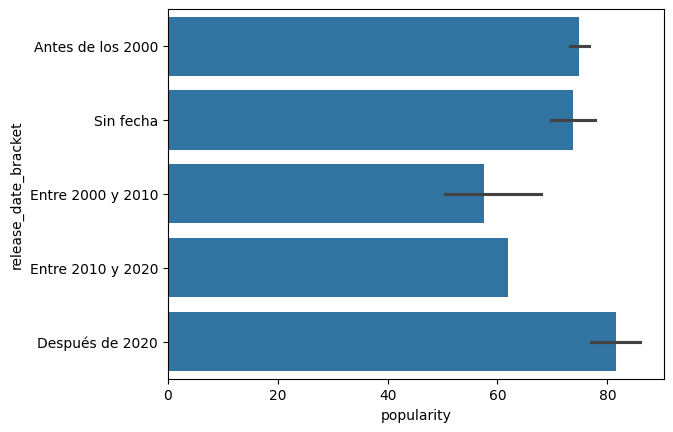

In [0]:
sns.barplot(x="popularity", y="release_date_bracket", data=df_all_songs)

In [0]:
print(f'popularuty mean: {df_all_songs.popularity.mean():.3f}')

popularuty mean: 74.070


<Axes: xlabel='popularity', ylabel='Count'>

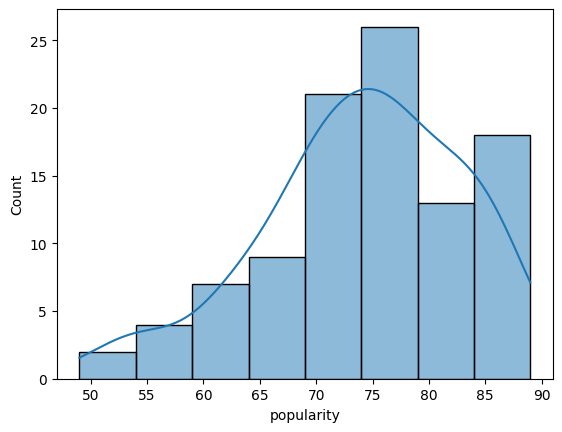

In [0]:
sns.histplot(df_all_songs, x='popularity', kde=True)

In [0]:
# statistics

df_all_songs.groupby('explicit').agg({
    'popularity': ['mean', 'median'],
    'track_name': 'nunique',
    'duration_min': ['mean', 'median'],
})

popularity        track_name duration_min          
               mean median    nunique         mean    median
explicit                                                    
False     74.170213   75.0         93     4.269429  4.063325
True      72.500000   72.0          6     4.458531  4.475442

<Axes: xlabel='popularity', ylabel='Density'>

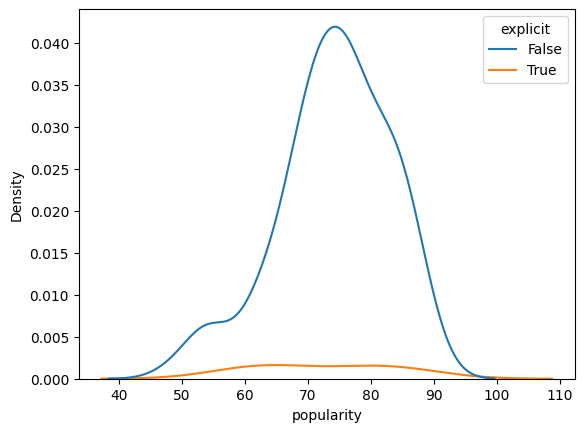

In [0]:
sns.kdeplot(data=df_all_songs, x="popularity", hue="explicit")

<Axes: xlabel='explicit', ylabel='popularity'>

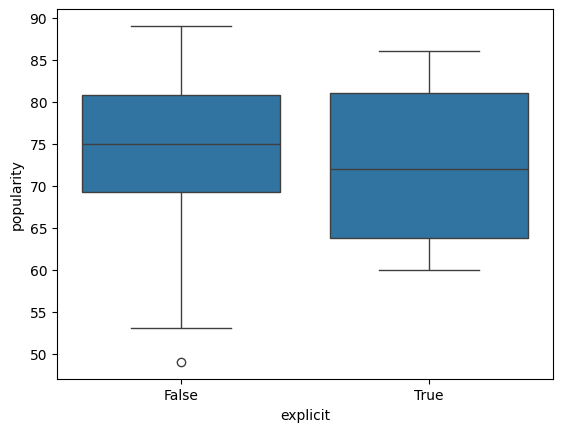

In [0]:
sns.boxplot(data=df_all_songs, x="explicit", y="popularity")

<Axes: xlabel='explicit', ylabel='duration_min'>

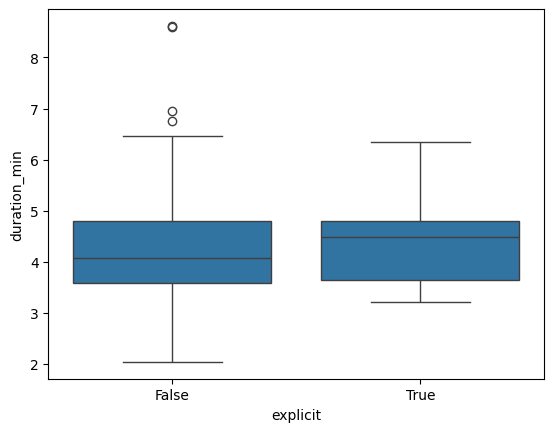

In [0]:
sns.boxplot(data=df_all_songs, x="explicit", y="duration_min")

In [0]:
df_all_songs.head()

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres
0,Thunderstruck,57bgtoPSgt236HzfBOd8kj,AC/DC,711MCceyCBcFnzjGY4Q7Un,AC/DC,1,89,False,The Razors Edge,album,12,1,185,1990-09-24,4.872217,1990.0,Antes de los 2000,34116016,82,"rock, hard rock, classic rock, rock and roll"
1,Welcome To The Jungle,0G21yYKMZoHa30cYVi1iA8,Guns N' Roses,3qm84nBOXUEQ2vnTfUTTFC,Guns N' Roses,1,86,True,Appetite For Destruction,album,12,1,183,1987-07-21,4.558000,1987.0,Antes de los 2000,37484999,80,"rock, glam metal, hard rock, classic rock"
2,Smells Like Teen Spirit,5ghIJDpPoe3CfHMGu71E6T,Nirvana,6olE6TJLqED3rqDCT0FyPh,Nirvana,1,83,False,Nevermind (Remastered),album,13,1,3,1991-09-26,5.032000,1991.0,Antes de los 2000,25417186,82,"grunge, rock"
3,Livin' On A Prayer,37ZJ0p5Jm13JPevGcx4SkF,Bon Jovi,58lV9VcRSjABbAbfWS6skp,Bon Jovi,1,84,False,Slippery When Wet,album,10,3,184,1986-08-16,4.154883,1986.0,Antes de los 2000,16950562,79,glam metal
4,I Was Made For Lovin' You,07q0QVgO56EorrSGHC48y3,KISS,07XSN3sPlIlB2L2XNcTwJw,KISS,1,87,False,Dynasty,album,9,1,183,1979-03-23,4.520667,1979.0,Antes de los 2000,11823844,72,"glam rock, glam metal, hard rock, rock, classi..."


<Axes: xlabel='popularity', ylabel='duration_min'>

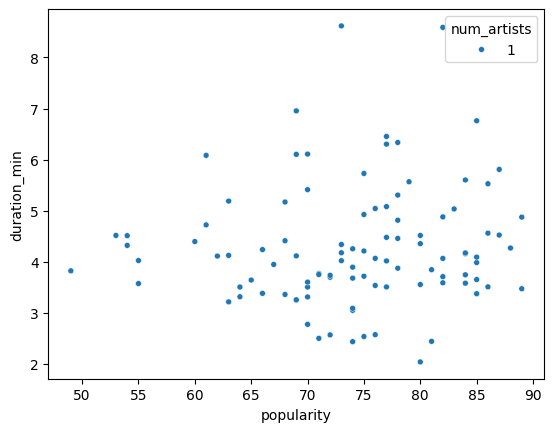

In [0]:
sns.scatterplot(data=df_all_songs, x='popularity', y='duration_min', size = 'num_artists')

In [0]:
print('h')

h


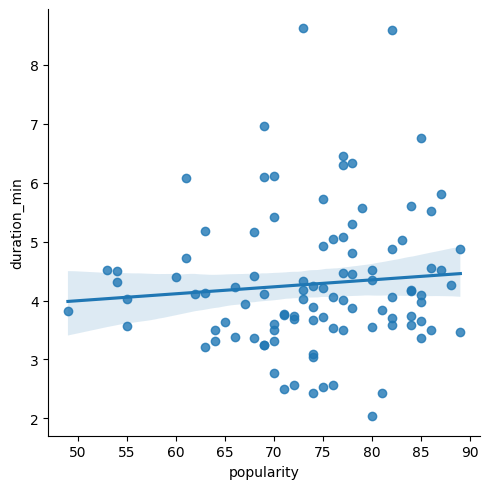

In [0]:
import matplotlib.ticker as ticker

g = sns.lmplot(
    data=df_all_songs,
    x="popularity",
    y="duration_min",
)

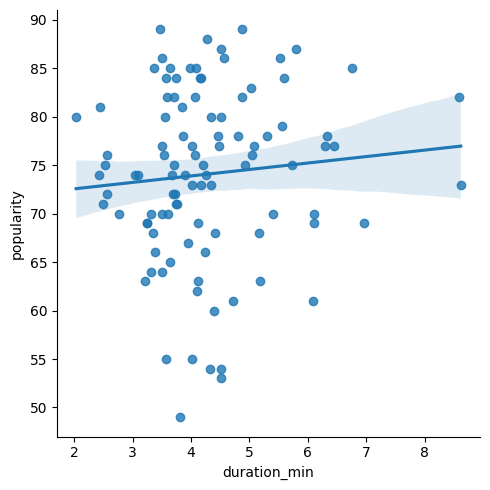

In [0]:
import matplotlib.ticker as ticker

g = sns.lmplot(
    data=df_all_songs,
    x="duration_min",
    y="popularity", 
)

# Collaboration analysis

Does having more artists on a track move popularity?

In [0]:
df_all_songs.groupby('num_artists').agg({
    'track_name': 'nunique',
    'popularity': ['mean', 'median'],
    'duration_min': 'mean',
})

track_name popularity        duration_min
               nunique       mean median         mean
num_artists                                          
1                   99      74.07   75.0     4.280775

In [0]:
df_all_songs[df_all_songs['num_artists'] > 3]

,track_name,track_id,artist_name,artist_id,all_artists,num_artists,popularity,explicit,album_name,album_type,total_tracks_album,track_number,num_markets,release_date,duration_min,release_year,release_date_bracket,artist_followers,artist_popularity,artist_genres


<Axes: xlabel='num_artists', ylabel='popularity'>

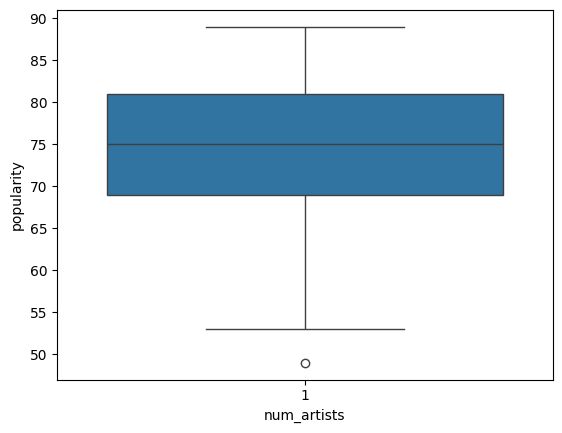

In [0]:
sns.boxplot(data=df_all_songs, x='num_artists', y='popularity')

In [0]:
# solo vs collab

df_all_songs['is_collab'] = df_all_songs['num_artists'] > 1
df_all_songs.groupby('is_collab').agg({
    'popularity': ['mean', 'median'],
    'track_name': 'nunique',
})

popularity        track_name
                mean median    nunique
is_collab                             
False          74.07   75.0         99

# Album type analysis

Single, album or compilation.

In [0]:
df_all_songs.groupby('album_type').agg({
    'track_name': 'nunique',
    'popularity': ['mean', 'median'],
    'duration_min': 'mean',
    'total_tracks_album': 'mean',
})

track_name popularity        duration_min total_tracks_album
               nunique       mean median         mean               mean
album_type                                                              
album               89  75.122222   75.5     4.260247               15.3
compilation         10  64.600000   67.0     4.465527               26.8

<Axes: xlabel='album_type', ylabel='popularity'>

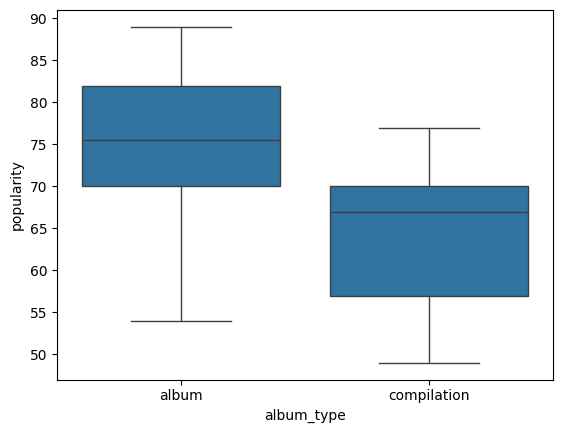

In [0]:
sns.boxplot(data=df_all_songs, x='album_type', y='popularity')

<Axes: xlabel='album_type', ylabel='count'>

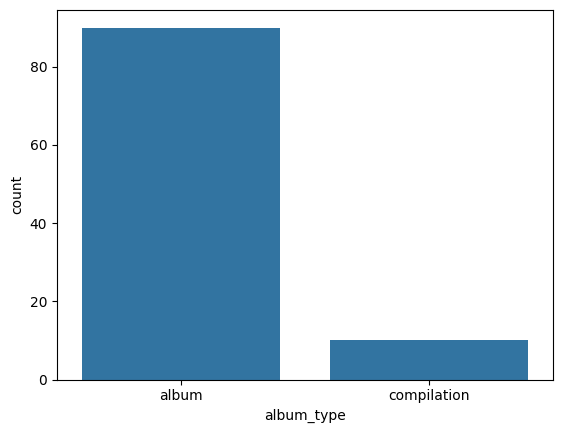

In [0]:
sns.countplot(data=df_all_songs, x='album_type')

# Market reach

Number of countries where each track is available.

In [0]:
df_all_songs['num_markets'].describe()

count    100.00000
mean     177.67000
std       26.19625
min        3.00000
25%      182.00000
50%      184.00000
75%      185.00000
max      185.00000
Name: num_markets, dtype: float64

<Axes: xlabel='num_markets', ylabel='Count'>

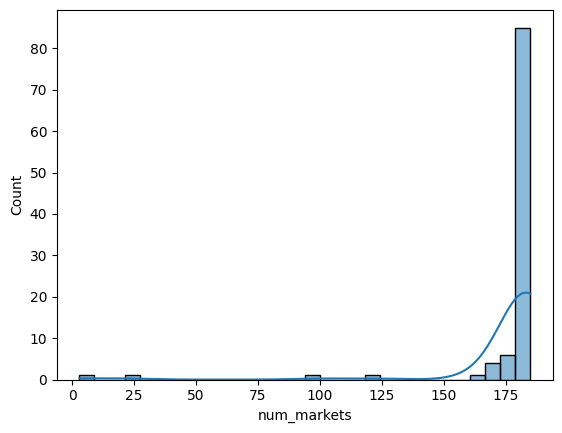

In [0]:
sns.histplot(df_all_songs, x='num_markets', bins=30, kde=True)

<Axes: xlabel='num_markets', ylabel='popularity'>

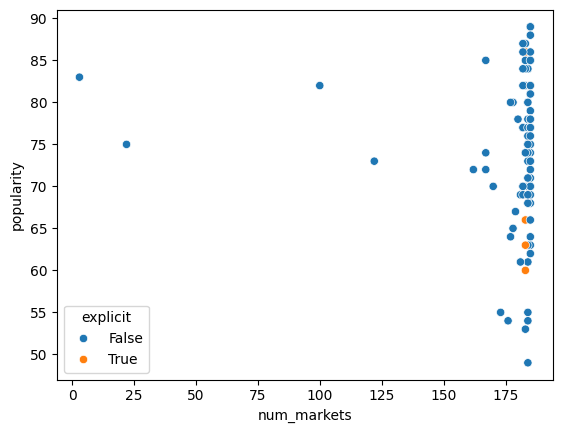

In [0]:
sns.scatterplot(data=df_all_songs, x='num_markets', y='popularity', hue='explicit')

# Artist popularity & followers vs track popularity

<Axes: xlabel='artist_popularity', ylabel='popularity'>

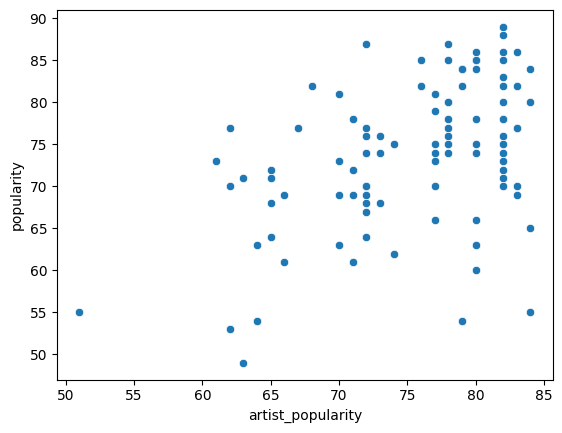

In [0]:
sns.scatterplot(data=df_all_songs, x='artist_popularity', y='popularity')

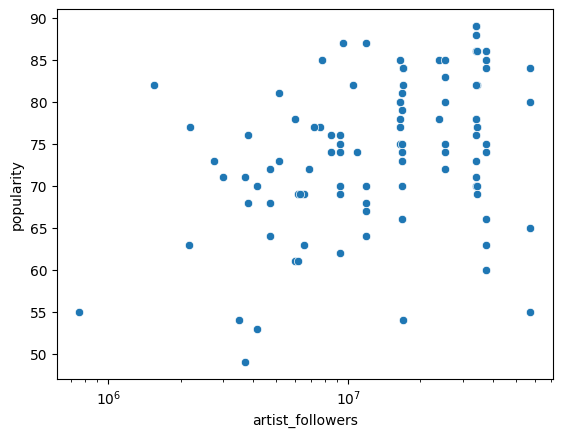

In [0]:
# log scale because followers are very skewed

ax = sns.scatterplot(data=df_all_songs, x='artist_followers', y='popularity')
ax.set_xscale('log')

In [0]:
# top 10 artists by followers in this playlist

df_all_songs.groupby('artist_name').agg({
    'artist_followers': 'max',
    'artist_popularity': 'max',
    'popularity': 'mean',
    'track_name': 'nunique',
}).sort_values('artist_followers', ascending=False).head(10)

,artist_followers,artist_popularity,popularity,track_name
artist_name,,,,
Queen,57432665,84,71.000000,4
Guns N' Roses,37484999,80,74.125000,8
Metallica,34504337,83,76.833333,6
AC/DC,34116016,82,80.000000,11
Nirvana,25417186,82,78.166667,6
Pink Floyd,23856120,80,81.500000,2
Bon Jovi,16950562,79,77.600000,4
Led Zeppelin,16743591,77,74.000000,7
The Rolling Stones,16437135,78,79.166667,6


# Genre analysis

In [0]:
# explode genres (artist_genres is a comma-joined string)

genre_counter = Counter()

for g in df_all_songs['artist_genres'].dropna():
    for genre in g.split(', '):
        genre_counter[genre.strip()] += 1

df_genres = pd.DataFrame(genre_counter.most_common(15), columns=['genre', 'count'])
df_genres

,genre,count
0,rock,64
1,classic rock,62
2,hard rock,50
3,glam metal,33
4,rock and roll,18
5,glam rock,17
6,metal,12
7,heavy metal,12
8,psychedelic rock,8
9,thrash metal,8


<Axes: xlabel='count', ylabel='genre'>

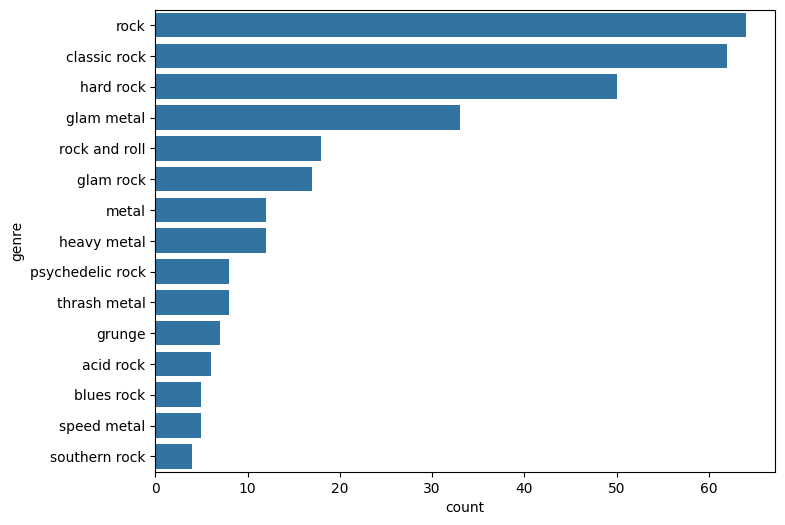

In [0]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df_genres, x='count', y='genre')

# Tracks per year

In [0]:
df_year = df_all_songs.groupby('release_year').agg({
    'track_name': 'nunique',
    'popularity': 'mean',
}).reset_index()

df_year

,release_year,track_name,popularity
0,1965.0,1,75.000000
1,1966.0,1,85.000000
2,1967.0,2,71.500000
3,1968.0,2,77.000000
4,1969.0,5,74.200000
5,1970.0,2,75.000000
6,1971.0,3,73.000000
7,1972.0,1,69.000000
8,1973.0,2,79.500000
9,1974.0,1,61.000000


<Axes: xlabel='release_year', ylabel='track_name'>

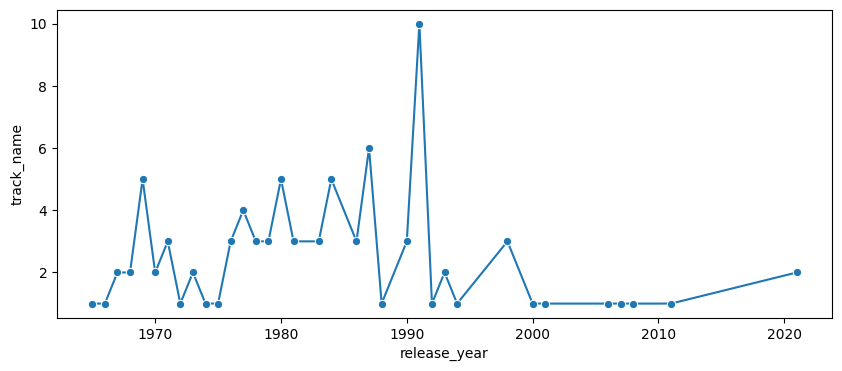

In [0]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_year, x='release_year', y='track_name', marker='o')

<Axes: xlabel='release_year', ylabel='popularity'>

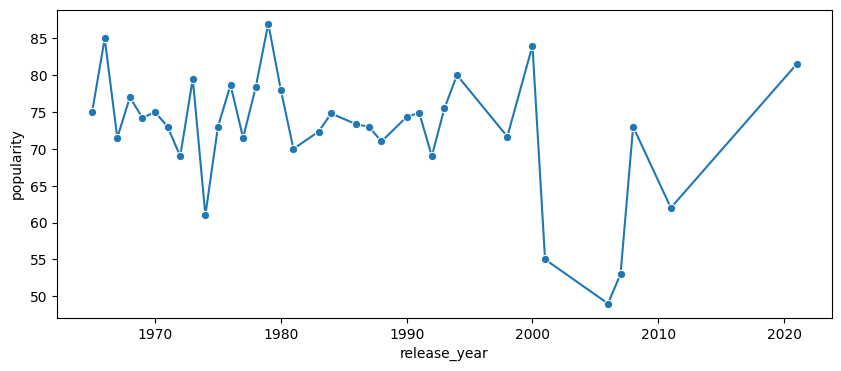

In [0]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_year, x='release_year', y='popularity', marker='o')

# Correlation heatmap

Numeric attributes against each other.

<Axes: >

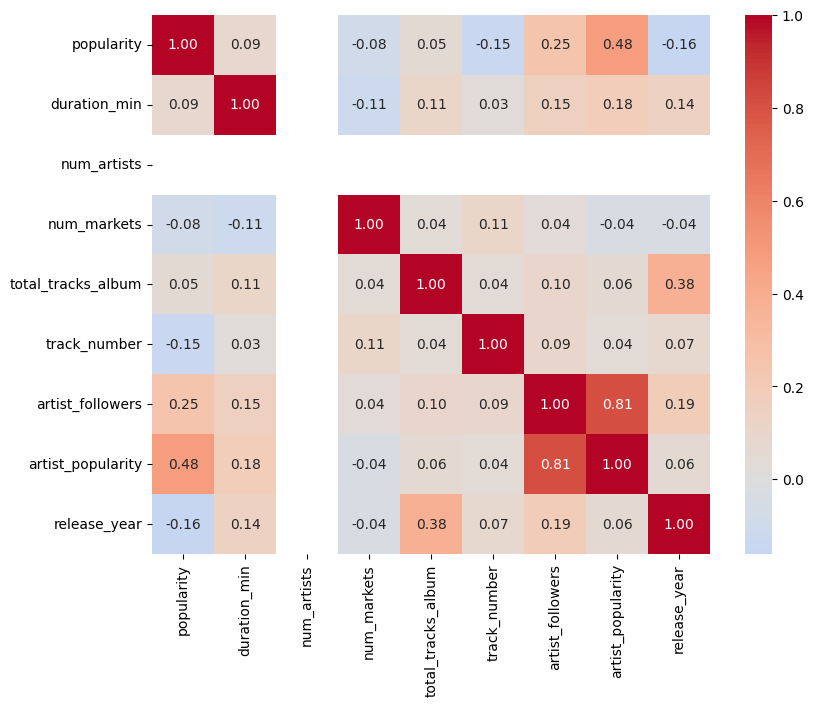

In [0]:
num_cols = [
    'popularity',
    'duration_min',
    'num_artists',
    'num_markets',
    'total_tracks_album',
    'track_number',
    'artist_followers',
    'artist_popularity',
    'release_year',
]

plt.figure(figsize=(9, 7))
sns.heatmap(df_all_songs[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')